**Base Template which will be saving the data**

In [69]:
# ============================================================
# Deep Learning Programming Assignment 2 (Keras / Colab)
# Part 1: CIFAR-10   (keras.datasets)
# Part 2: CIFAR-100  (keras.datasets)
# Part 3: Animal10   (image_dataset_from_directory, 20% split)
# Saves: best/last full model (.keras) + best/last weights (.weights.h5) + logs
# ============================================================

# ----------------------------
# 0) CHOOSE PART + RUN NAME
# ----------------------------
PART = 1  # <-- set to 1, 2, or 3
RUN_NAME = f"part{PART}_run1"  # change for new experiments (run2, run3...)

# For Part 3 dataset path (your folder structure)
ANIMAL_DIR = "/content/drive/MyDrive/AnimalsData/Animals10/raw-img"



---



**1. MOUNT DRIVE + FOLDERS**



---



In [70]:
# ----------------------------
# 1) Mount Drive + folders
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

import os, json, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/DL_Prog2"
RUN_DIR = os.path.join(PROJECT_DIR, RUN_NAME)

CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
LOG_DIR  = os.path.join(RUN_DIR, "logs")
OUT_DIR  = os.path.join(RUN_DIR, "outputs")

for d in [CKPT_DIR, LOG_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

print("RUN_DIR:", RUN_DIR)
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUN_DIR: /content/drive/MyDrive/DL_Prog2/part1_run1
TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]




---



**2. CONFIG + REPRODUCIBILITY**



---



In [71]:
# ----------------------------
# 2) Config + reproducibility
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Recommended defaults (edit if needed)
CONFIG = {
    "part": PART,
    "seed": SEED,
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "val_split": 0.2,       # Part 3 requires 20% testing/validation
    "img_size_part3": 96,   # 64 faster; 128 potentially better
}

with open(os.path.join(RUN_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

CONFIG

{'part': 1,
 'seed': 42,
 'epochs': 30,
 'batch_size': 64,
 'lr': 0.001,
 'val_split': 0.2,
 'img_size_part3': 96}



---



**3. HELPER FUNCTIONS**



---



In [72]:
# ----------------------------
# 3) Helper: show samples + plotting
# ----------------------------
def show_samples_np(x, y, n=12):
    idx = np.random.choice(len(x), n, replace=False)
    plt.figure(figsize=(12,4))
    for i, k in enumerate(idx):
        plt.subplot(2, n//2, i+1)
        plt.imshow(x[k])
        plt.title(str(int(y[k])))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_accuracy_from_csv(csv_path, title="Accuracy vs Epoch"):
    df = pd.read_csv(csv_path)
    epochs_axis = np.arange(len(df))
    plt.figure()
    if "accuracy" in df.columns:
        plt.plot(epochs_axis, df["accuracy"], label="train_acc")
    if "val_accuracy" in df.columns:
        plt.plot(epochs_axis, df["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()



---



**4. DATA AUGMENTATION + MODEL BUILDERS**



---



In [73]:
# ----------------------------
# 4) Data augmentation + model builders
# ----------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def build_cnn(input_shape, num_classes, lr):
    inputs = tf.keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = tf.keras.layers.Rescaling(1./255)(x)  # expects uint8 images

    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model



---



**5. SAVING + RESUME LOGIC**



---



In [74]:
# ----------------------------
# 5) Saving + resume logic (works for all parts)
# ----------------------------
best_full  = os.path.join(CKPT_DIR, "best.keras")
last_full  = os.path.join(CKPT_DIR, "last.keras")
best_wts   = os.path.join(CKPT_DIR, "best.weights.h5")
last_wts   = os.path.join(CKPT_DIR, "last.weights.h5")

csv_log    = os.path.join(LOG_DIR, "history.csv")
tb_logdir  = os.path.join(LOG_DIR, "tensorboard")

callbacks = [
    # Full model (architecture + weights + optimizer state)
    tf.keras.callbacks.ModelCheckpoint(best_full, monitor="val_accuracy", mode="max",
                                       save_best_only=True, save_weights_only=False),
    tf.keras.callbacks.ModelCheckpoint(last_full, monitor="val_accuracy", mode="max",
                                       save_best_only=False, save_weights_only=False),

    # Weights-only (if someone wants to rebuild model code)
    tf.keras.callbacks.ModelCheckpoint(best_wts, monitor="val_accuracy", mode="max",
                                       save_best_only=True, save_weights_only=True),
    tf.keras.callbacks.ModelCheckpoint(last_wts, monitor="val_accuracy", mode="max",
                                       save_best_only=False, save_weights_only=True),

    tf.keras.callbacks.CSVLogger(csv_log, append=True),
    tf.keras.callbacks.TensorBoard(log_dir=tb_logdir),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=8, restore_best_weights=True)
]

def get_initial_epoch_from_csv(csv_path: str) -> int:
    # If file doesn't exist or is empty -> start from epoch 0
    if (not os.path.exists(csv_path)) or os.path.getsize(csv_path) == 0:
        return 0

    try:
        df = pd.read_csv(csv_path)
        # If somehow it has headers but no rows, still 0
        return int(len(df))
    except pd.errors.EmptyDataError:
        return 0
    except Exception as e:
        # If it's corrupted, safest is to restart or rename it
        print(f"[WARN] Could not read CSV log ({csv_path}): {e}. Starting from epoch 0.")
        return 0

def maybe_resume_or_build(input_shape, num_classes, lr):
    initial_epoch = get_initial_epoch_from_csv(csv_log)

    if os.path.exists(last_full):
        print("Resuming from:", last_full)
        model = tf.keras.models.load_model(last_full)
        print("Initial epoch:", initial_epoch)
        return model, initial_epoch

    print("No checkpoint found. Building new model.")
    model = build_cnn(input_shape, num_classes, lr)
    return model, 0



---



**PART 1: CIFAR-10 (Keras)**



---



Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


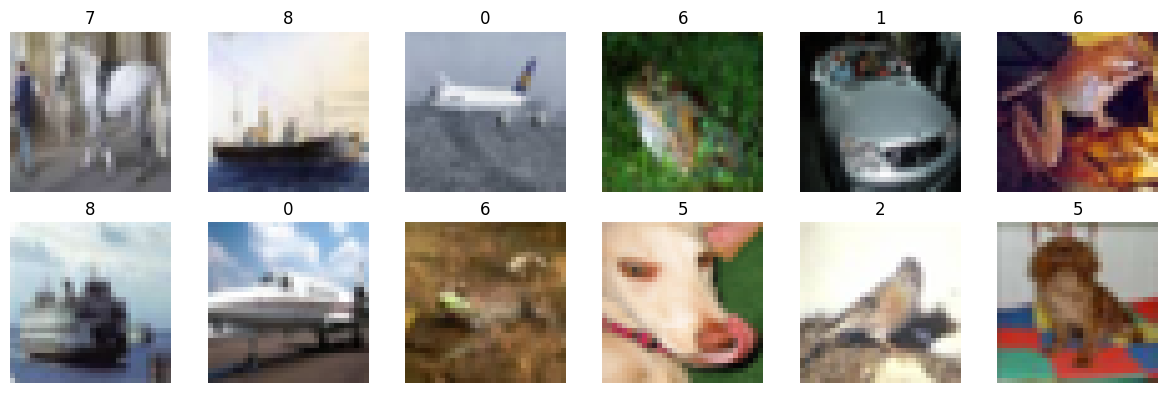

Resuming from: /content/drive/MyDrive/DL_Prog2/part1_run1/checkpoints/last.keras
Initial epoch: 30


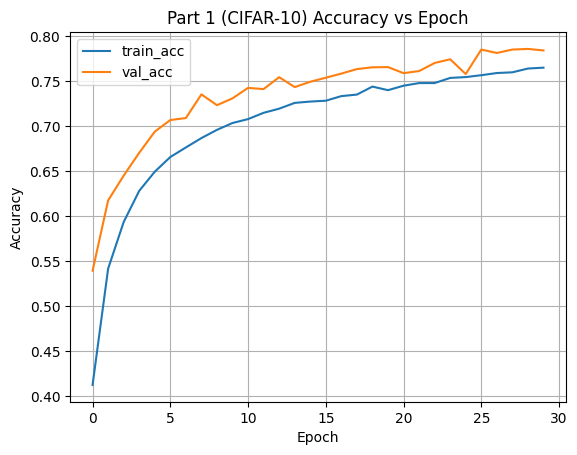

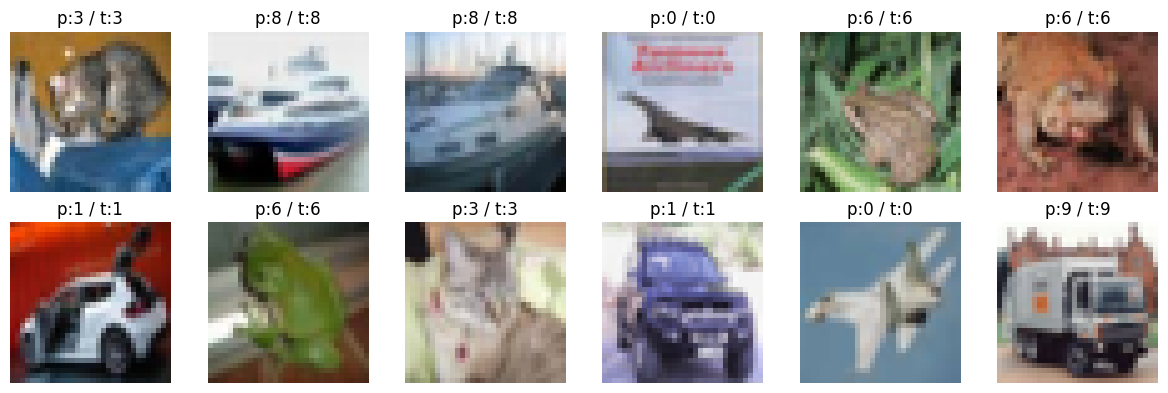

In [75]:
if PART == 1:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    y_train = y_train.squeeze()
    y_test  = y_test.squeeze()

    # Keep as uint8 for Rescaling(1./255) layer
    x_train = x_train.astype("uint8")
    x_test  = x_test.astype("uint8")

    print("Train:", x_train.shape, y_train.shape)
    print("Test :", x_test.shape, y_test.shape)

    # Visualize some images:
    show_samples_np(x_train, y_train, n=12)

    input_shape = (32, 32, 3)
    num_classes = 10

    model, initial_epoch = maybe_resume_or_build(input_shape, num_classes, CONFIG["lr"])

    # Save model summary (useful for grading)
    with open(os.path.join(RUN_DIR, "model_summary.txt"), "w") as f:
        model.summary(print_fn=lambda s: f.write(s + "\n"))

    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=CONFIG["epochs"],
        initial_epoch=initial_epoch,
        batch_size=CONFIG["batch_size"],
        callbacks=callbacks,
        verbose=1
    )

    # Visualize model accuracy over training epochs for both training and validation datasets
    plot_accuracy_from_csv(csv_log, title="Part 1 (CIFAR-10) Accuracy vs Epoch")


    # -------------------------------------------------
    # Display model predictions on test images
    # Shows predicted label (p) vs true label (t)
    # Used to visually evaluate model performance
    # -------------------------------------------------
    preds = model.predict(x_test[:32], verbose=0).argmax(axis=1)
    plt.figure(figsize=(12,4))
    for i in range(12):
        plt.subplot(2, 6, i+1)
        plt.imshow(x_test[i])
        plt.title(f"p:{preds[i]} / t:{y_test[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Print Best Training and Validation Accuracy

In [76]:
# ----------------------------
# Print best accuracy values
# ----------------------------
df = pd.read_csv(csv_log)

if "accuracy" in df.columns:
    best_train_acc = df["accuracy"].max()
    final_train_acc = df["accuracy"].iloc[-1]
    print(f"Best Train Accuracy  : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
    print(f"Final Train Accuracy : {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")

if "val_accuracy" in df.columns:
    best_val_acc = df["val_accuracy"].max()
    final_val_acc = df["val_accuracy"].iloc[-1]
    print(f"Best Validation Accuracy  : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"Final Validation Accuracy : {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

Best Train Accuracy  : 0.7649 (76.49%)
Final Train Accuracy : 0.7649 (76.49%)
Best Validation Accuracy  : 0.7857 (78.57%)
Final Validation Accuracy : 0.7840 (78.40%)




---



**PART 2: CIFAR-100 (Keras)**



---



In [77]:
# Select which assignment part to run
PART = 2     # 1 = CIFAR10
             # 2 = CIFAR100
             # 3 = Animal10

RUN_NAME = f"part{PART}_run1"

In [78]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/DL_Prog2"
RUN_NAME = "part2_run1"

RUN_DIR = os.path.join(PROJECT_DIR, RUN_NAME)

CHECKPOINT_DIR = os.path.join(RUN_DIR, "checkpoints")
LOG_DIR = os.path.join(RUN_DIR, "logs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)
print("Log directory:", LOG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint directory: /content/drive/MyDrive/DL_Prog2/part2_run1/checkpoints
Log directory: /content/drive/MyDrive/DL_Prog2/part2_run1/logs


Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


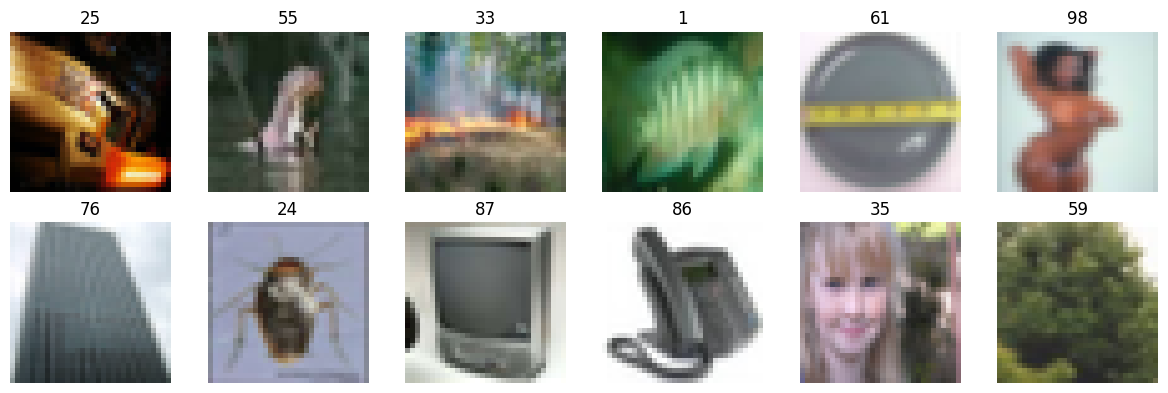

Resuming from: /content/drive/MyDrive/DL_Prog2/part1_run1/checkpoints/last.keras
Initial epoch: 30


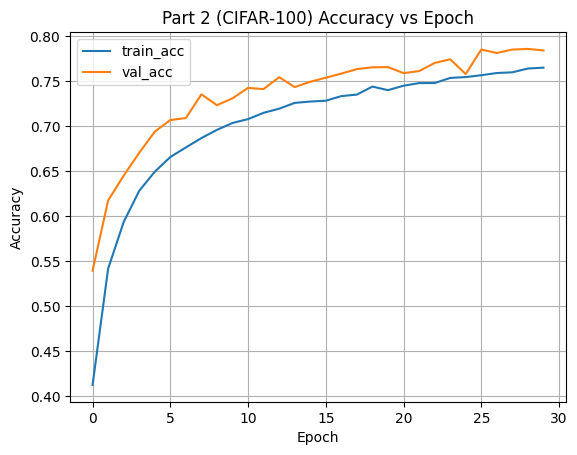

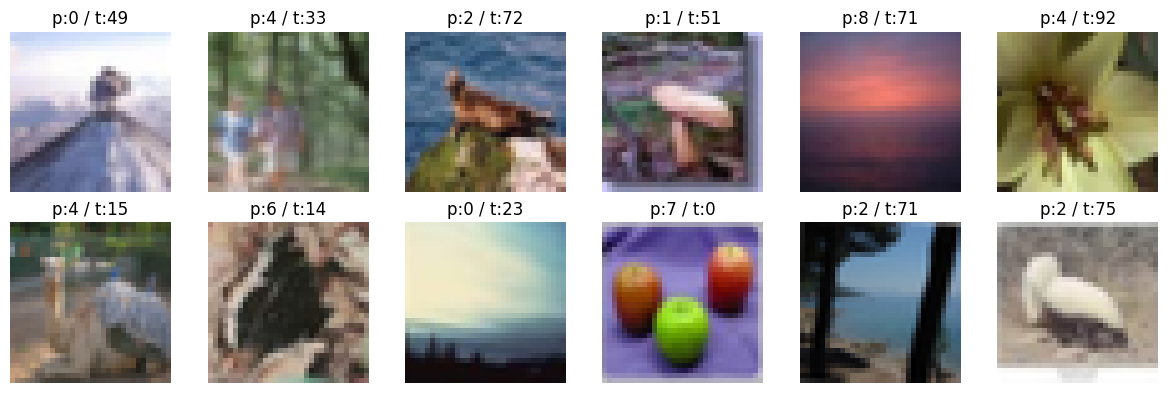

In [79]:
if PART == 2:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
    y_train = y_train.squeeze()
    y_test  = y_test.squeeze()

    # Keep as uint8 for Rescaling(1./255) layer
    x_train = x_train.astype("uint8")
    x_test  = x_test.astype("uint8")

    print("Train:", x_train.shape, y_train.shape)
    print("Test :", x_test.shape, y_test.shape)

    # Visualize some images (required)
    show_samples_np(x_train, y_train, n=12)

    input_shape = (32, 32, 3)
    num_classes = 100

    model, initial_epoch = maybe_resume_or_build(input_shape, num_classes, CONFIG["lr"])

    # Save model summary (useful for grading)
    with open(os.path.join(RUN_DIR, "model_summary.txt"), "w") as f:
        model.summary(print_fn=lambda s: f.write(s + "\n"))

    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=CONFIG["epochs"],
        initial_epoch=initial_epoch,
        batch_size=CONFIG["batch_size"],
        callbacks=callbacks,
        verbose=1
    )

    # Plot accuracy over epochs (required)
    plot_accuracy_from_csv(csv_log, title="Part 2 (CIFAR-100) Accuracy vs Epoch")

    # Show some predictions (required)
    preds = model.predict(x_test[:32], verbose=0).argmax(axis=1)
    plt.figure(figsize=(12,4))
    for i in range(12):
        plt.subplot(2, 6, i+1)
        plt.imshow(x_test[i])
        plt.title(f"p:{preds[i]} / t:{y_test[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Print Best Training and Validation Accuracy

In [80]:
# ----------------------------
# Print best accuracy values
# ----------------------------
df = pd.read_csv(csv_log)

if "accuracy" in df.columns:
    best_train_acc = df["accuracy"].max()
    final_train_acc = df["accuracy"].iloc[-1]
    print(f"Best Train Accuracy  : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
    print(f"Final Train Accuracy : {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")

if "val_accuracy" in df.columns:
    best_val_acc = df["val_accuracy"].max()
    final_val_acc = df["val_accuracy"].iloc[-1]
    print(f"Best Validation Accuracy  : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"Final Validation Accuracy : {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

Best Train Accuracy  : 0.7649 (76.49%)
Final Train Accuracy : 0.7649 (76.49%)
Best Validation Accuracy  : 0.7857 (78.57%)
Final Validation Accuracy : 0.7840 (78.40%)




---



**PART 3: Animal10**



---



In [81]:
# Select which assignment part to run
PART = 3     # 1 = CIFAR10
             # 2 = CIFAR100
             # 3 = Animal10

RUN_NAME = f"part{PART}_run1"

In [82]:
from google.colab import drive
drive.mount('/content/drive')

import os

# controller
# PART = 3
RUN_NAME = f"part{PART}_run1"

PROJECT_DIR = "/content/drive/MyDrive/DL_Prog2"
RUN_DIR = os.path.join(PROJECT_DIR, RUN_NAME)

CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
LOG_DIR  = os.path.join(RUN_DIR, "logs")
OUT_DIR  = os.path.join(RUN_DIR, "outputs")

for d in [CKPT_DIR, LOG_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

print("RUN_DIR:", RUN_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("LOG_DIR :", LOG_DIR)
print("OUT_DIR :", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUN_DIR: /content/drive/MyDrive/DL_Prog2/part3_run1
CKPT_DIR: /content/drive/MyDrive/DL_Prog2/part3_run1/checkpoints
LOG_DIR : /content/drive/MyDrive/DL_Prog2/part3_run1/logs
OUT_DIR : /content/drive/MyDrive/DL_Prog2/part3_run1/outputs


Found 26180 files belonging to 10 classes.
Using 20944 files for training.
Found 26180 files belonging to 10 classes.
Using 5236 files for validation.
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
num_classes: 10
Batch: (64, 96, 96, 3) <dtype: 'float32'>


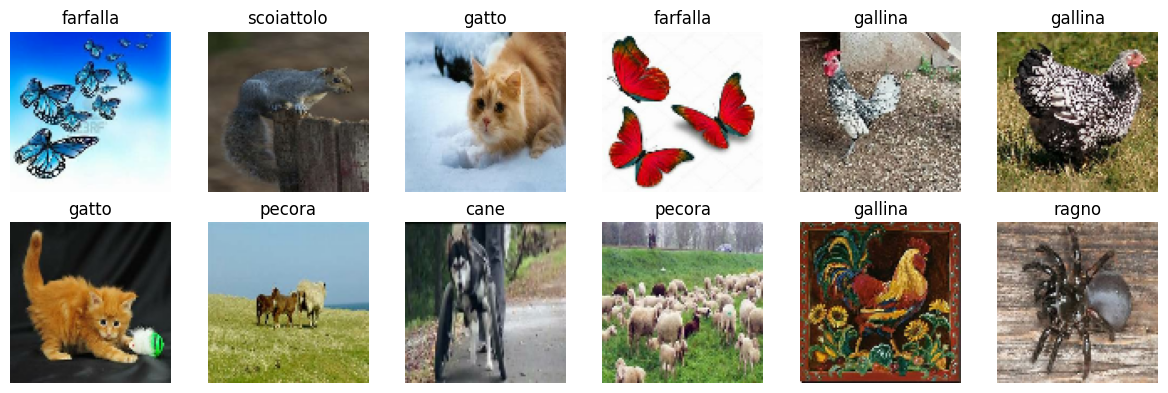

Train counts:
cane        : 3907
cavallo     : 2089
elefante    : 1190
farfalla    : 1706
gallina     : 2458
gatto       : 1364
mucca       : 1503
pecora      : 1457
ragno       : 3796
scoiattolo  : 1474
Class weights: {0: np.float64(0.536063475812644), 1: np.float64(1.0025849688846338), 2: np.float64(1.76), 3: np.float64(1.2276670574443143), 4: np.float64(0.8520748576078112), 5: np.float64(1.5354838709677419), 6: np.float64(1.3934797072521623), 7: np.float64(1.437474262182567), 8: np.float64(0.5517386722866174), 9: np.float64(1.4208955223880597)}
Resuming from: /content/drive/MyDrive/DL_Prog2/part3_run1/checkpoints/last.keras
Initial epoch: 30



=== Phase 1: Frozen base ===


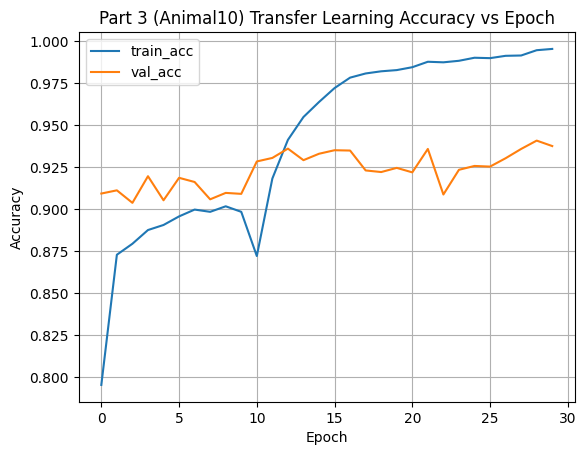

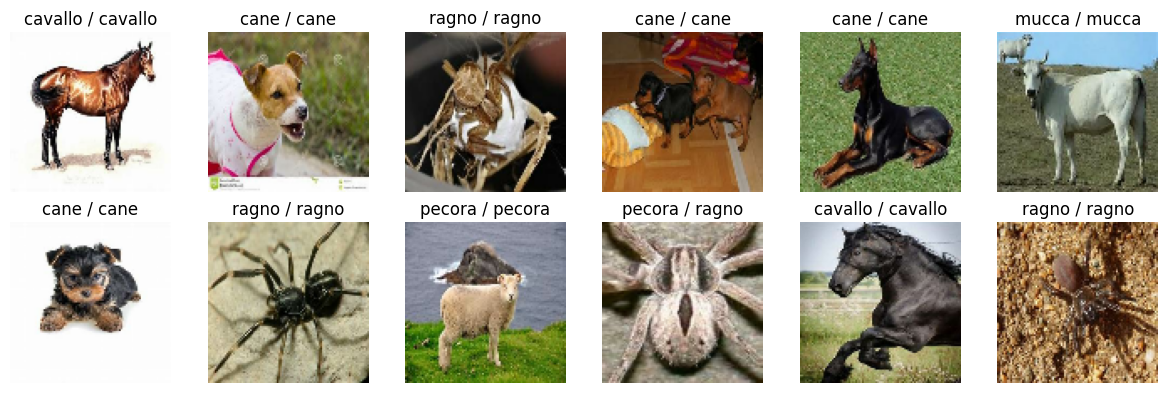


Saved:
 - best: /content/drive/MyDrive/DL_Prog2/part3_run1/checkpoints/best.keras
 - last: /content/drive/MyDrive/DL_Prog2/part3_run1/checkpoints/last.keras
 - log : /content/drive/MyDrive/DL_Prog2/part3_run1/logs/history.csv
 - class_names.json + config.json + model_summary.txt in RUN_DIR


In [83]:
if PART == 3:
    import os, json
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    import matplotlib.pyplot as plt

    # ----------------------------
    # 1) Dataset path (yours)
    # ----------------------------
    ANIMAL_DIR = "/content/drive/MyDrive/AnimalsData/Animals10/raw-img"
    assert os.path.exists(ANIMAL_DIR), f"Not found: {ANIMAL_DIR}"

    IMG_SIZE = CONFIG.get("img_size_part3", 224)
    BATCH = CONFIG["batch_size"]
    VAL_SPLIT = CONFIG.get("val_split", 0.2)
    SEED = CONFIG.get("seed", 42)

    AUTOTUNE = tf.data.AUTOTUNE

    # ----------------------------
    # 2) Load with image_dataset_from_directory
    # ----------------------------
    train_ds = tf.keras.utils.image_dataset_from_directory(
        ANIMAL_DIR,
        validation_split=VAL_SPLIT,
        subset="training",
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        ANIMAL_DIR,
        validation_split=VAL_SPLIT,
        subset="validation",
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH,
        label_mode="int"
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)
    print("Classes:", class_names)
    print("num_classes:", num_classes)

    # Save class mapping for grading
    with open(os.path.join(RUN_DIR, "class_names.json"), "w") as f:
        json.dump(class_names, f, indent=2)

    # ----------------------------
    # 3) Explore: show a batch + distribution
    # ----------------------------
    def show_ds_samples(ds, class_names, n=12):
        plt.figure(figsize=(12,4))
        for images, labels in ds.take(1):
            print("Batch:", images.shape, images.dtype)
            for i in range(min(n, images.shape[0])):
                plt.subplot(2, n//2, i+1)
                plt.imshow(images[i].numpy().astype("uint8"))
                plt.title(class_names[int(labels[i])])
                plt.axis("off")
        plt.tight_layout()
        plt.show()

    def class_distribution(ds, num_classes):
        counts = np.zeros(num_classes, dtype=np.int64)
        for _, labels in ds:
            labels_np = labels.numpy()
            for c in labels_np:
                counts[int(c)] += 1
        return counts

    show_ds_samples(train_ds, class_names, n=12)

    counts = class_distribution(train_ds, num_classes)
    print("Train counts:")
    for name, c in zip(class_names, counts.tolist()):
        print(f"{name:12s}: {c}")

    # Class weights (helps imbalance without complicated sampling)
    total = counts.sum()
    class_weight = {i: (total / (num_classes * max(counts[i], 1))) for i in range(num_classes)}
    print("Class weights:", class_weight)

    # Speed pipeline
    train_ds = train_ds.cache().shuffle(2000, seed=SEED).prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)

    # ----------------------------
    # 4) Transfer learning model (MobileNetV2)
    # ----------------------------
    # Data augmentation
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.15),
        tf.keras.layers.RandomTranslation(0.05, 0.05),
    ])

    def build_transfer_model(num_classes, img_size, lr, base_trainable=False):
        inputs = tf.keras.Input(shape=(img_size, img_size, 3))
        x = data_augmentation(inputs)

        # MobileNetV2 expects pixel values in [-1, 1]
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

        base = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        base.trainable = base_trainable  # False for feature extraction phase

        x = base(x, training=False)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dropout(0.3)(x)
        x = tf.keras.layers.Dense(256, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

        model = tf.keras.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(lr),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        return model

    # ----------------------------
    # 5) Resume helpers (Part 3)
    # ----------------------------
    last_full = os.path.join(CKPT_DIR, "last.keras")
    best_full = os.path.join(CKPT_DIR, "best.keras")
    csv_log   = os.path.join(LOG_DIR, "history.csv")

    def initial_epoch_from_csv(path):
        if not os.path.exists(path):
            return 0
        df = pd.read_csv(path)
        return len(df)

    # If a checkpoint exists, load it; otherwise build new
    if os.path.exists(last_full):
        print("Resuming from:", last_full)
        model = tf.keras.models.load_model(last_full)
        initial_epoch = initial_epoch_from_csv(csv_log)
        print("Initial epoch:", initial_epoch)
    else:
        # Phase 1: feature extraction (base frozen)
        model = build_transfer_model(num_classes, IMG_SIZE, lr=CONFIG["lr"], base_trainable=False)
        initial_epoch = 0

    # Save model summary
    with open(os.path.join(RUN_DIR, "model_summary.txt"), "w") as f:
        model.summary(print_fn=lambda s: f.write(s + "\n"))

    # ----------------------------
    # 6) Callbacks (best/last + logs) - reuse yours if already defined
    # ----------------------------
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(best_full, monitor="val_accuracy", mode="max",
                                           save_best_only=True, save_weights_only=False),
        tf.keras.callbacks.ModelCheckpoint(last_full, monitor="val_accuracy", mode="max",
                                           save_best_only=False, save_weights_only=False),
        tf.keras.callbacks.CSVLogger(csv_log, append=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=6,
                                         restore_best_weights=True),
    ]

    # ----------------------------
    # 7) Train Phase 1 (frozen base)
    # ----------------------------
    EPOCHS_TOTAL = CONFIG["epochs"]
    phase1_epochs = min(10, EPOCHS_TOTAL)  # quick head training

    print("\n=== Phase 1: Frozen base ===")
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=phase1_epochs,
        initial_epoch=initial_epoch,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1
    )

    # ----------------------------
    # 8) Fine-tuning Phase 2 (unfreeze last layers)
    # ----------------------------
    # Only fine-tune if we still have epochs left
    current_epoch = initial_epoch_from_csv(csv_log)
    if current_epoch < EPOCHS_TOTAL:
        print("\n=== Phase 2: Fine-tuning ===")

        # Unfreeze the base model if present
        # Find MobileNetV2 layer by type/name
        base_model = None
        for layer in model.layers:
            if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
                base_model = layer
                break

        if base_model is not None:
            base_model.trainable = True

            # Fine-tune only the last N layers (keeps training stable)
            fine_tune_at = max(0, len(base_model.layers) - 60)
            for l in base_model.layers[:fine_tune_at]:
                l.trainable = False

            # Use smaller LR for fine-tuning
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                loss=tf.keras.losses.SparseCategoricalCrossentropy( ),
                metrics=["accuracy"]
            )

        history2 = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_TOTAL,
            initial_epoch=current_epoch,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=1
        )

    # ----------------------------
    # 9) Plot accuracy vs epochs
    # ----------------------------
    df = pd.read_csv(csv_log)
    epochs_axis = np.arange(len(df))

    plt.figure()
    if "accuracy" in df.columns:
        plt.plot(epochs_axis, df["accuracy"], label="train_acc")
    if "val_accuracy" in df.columns:
        plt.plot(epochs_axis, df["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Part 3 (Animal10) Transfer Learning Accuracy vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # 10) Show some predictions
    # ----------------------------
    best_model = tf.keras.models.load_model(best_full)
    for images, labels in val_ds.take(1):
        preds = best_model.predict(images, verbose=0).argmax(axis=1)
        plt.figure(figsize=(12,4))
        for i in range(12):
            plt.subplot(2, 6, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"{class_names[int(preds[i])]} / {class_names[int(labels[i])]}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

    print("\nSaved:")
    print(" - best:", best_full)
    print(" - last:", last_full)
    print(" - log :", csv_log)
    print(" - class_names.json + config.json + model_summary.txt in RUN_DIR")

Print Best Training and Validation Accuracy

In [84]:
# ----------------------------
# 11) Print final and best accuracy
# ----------------------------
df = pd.read_csv(csv_log)

if "accuracy" in df.columns:
    final_train_acc = df["accuracy"].iloc[-1]
    best_train_acc = df["accuracy"].max()
    print(f"Final Train Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")

if "val_accuracy" in df.columns:
    final_val_acc = df["val_accuracy"].iloc[-1]
    best_val_acc = df["val_accuracy"].max()
    print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"Best Validation Accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

Final Train Accuracy: 0.9954 (99.54%)
Best Train Accuracy : 0.9954 (99.54%)
Final Validation Accuracy: 0.9375 (93.75%)
Best Validation Accuracy : 0.9408 (94.08%)


**FOR TESTING**

In [85]:
# ==============================
# Load Best Model for External Testing
# ==============================

import tensorflow as tf
import numpy as np
import json

print("Loading best trained model...")

best_model = tf.keras.models.load_model(best_full)

print("Model loaded successfully.")

# Load class names
with open(os.path.join(RUN_DIR, "class_names.json"), "r") as f:
    class_names = json.load(f)

print("Classes:", class_names)


# ------------------------------
# Function to predict new images
# ------------------------------
IMG_SIZE = 224

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = best_model.predict(img_array)
    pred_class = class_names[np.argmax(preds)]

    print("Prediction:", pred_class)
    return pred_class

Loading best trained model...
Model loaded successfully.
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


### Example usage: Replace "some_new_animal.jpg" with the path to any image you want to classify

predict_image("new_animal.jpg")